In [ ]:
# ShopRocket Operations Analytics
## Notebook 3 — Seller Health Analysis & Segmentation

**Objective:** Analyze seller performance, build a Health Score, and segment sellers into tiers based on their behavior.

**Author:** Sadique Shoaib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Processed data load karo ───────────────────────────
SAVE_PATH = 'C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/data/processed/'

orders      = pd.read_csv(SAVE_PATH + 'orders_enriched.csv',
                          parse_dates=[
                            'order_purchase_timestamp',
                            'order_approved_at',
                            'order_delivered_carrier_date',
                            'order_delivered_customer_date',
                            'order_estimated_delivery_date'
                          ])
order_items = pd.read_csv(SAVE_PATH + 'order_items.csv')
reviews     = pd.read_csv(SAVE_PATH + 'reviews_clean.csv')
sellers     = pd.read_csv(SAVE_PATH + 'sellers.csv')

print("Data loaded!")
print(f"Orders     : {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Reviews    : {reviews.shape}")
print(f"Sellers    : {sellers.shape}")

✅ Data loaded!
Orders     : (99441, 13)
Order Items: (112650, 8)
Reviews    : (99224, 4)
Sellers    : (3095, 4)


In [4]:
# ── Step 1: Orders + Order Items join karo ─────────────
orders_items = order_items.merge(
    orders[['order_id', 'order_status', 
            'is_sla_breached', 'fulfillment_center',
            'carrier', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

print(f"Orders + Items joined: {orders_items.shape}")
print(f"\nColumns: {list(orders_items.columns)}")

Orders + Items joined: (112650, 13)

Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'seller_tier', 'order_status', 'is_sla_breached', 'fulfillment_center', 'carrier', 'order_purchase_timestamp']


In [5]:
# ── Step 2: Reviews join karo ──────────────────────────
orders_items_reviews = orders_items.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

print(f"Reviews bhi join ho gayi: {orders_items_reviews.shape}")
print(f"\nSample data:")
print(orders_items_reviews[['seller_id', 'order_status', 
                             'is_sla_breached', 'price',
                             'review_score']].head())

✅ Reviews bhi join ho gayi: (113314, 14)

Sample data:
                          seller_id order_status  is_sla_breached  price  \
0  48436dade18ac8b2bce089ec2a041202    delivered                0  58.90   
1  dd7ddc04e1b6c2c614352b383efe2d36    delivered                0 239.90   
2  5b51032eddd242adc84c38acab88f23d    delivered                0 199.00   
3  9d7a1d34a5052409006425275ba1c2b4    delivered                0  12.99   
4  df560393f3a51e74553ab94004ba5c87    delivered                0 199.90   

   review_score  
0          5.00  
1          4.00  
2          5.00  
3          4.00  
4          5.00  


In [ ]:
## Step 2 — Seller Performance Summary
Har seller ka: total orders, revenue, cancel rate, 
SLA breach rate, avg review score

In [6]:
# ── Seller level aggregation ───────────────────────────
seller_summary = (
    orders_items_reviews
    .groupby('seller_id')
    .agg(
        total_orders    = ('order_id', 'nunique'),
        total_revenue   = ('price', 'sum'),
        avg_order_value = ('price', 'mean'),
        cancel_rate     = ('order_status', lambda x: 
                          (x == 'canceled').sum() / len(x) * 100),
        sla_breach_rate = ('is_sla_breached', 'mean'),
        avg_review      = ('review_score', 'mean'),
        seller_tier     = ('seller_tier', 'first')
    )
    .reset_index()
)

# Round karo
seller_summary['cancel_rate']     = seller_summary['cancel_rate'].round(2)
seller_summary['sla_breach_rate'] = (seller_summary['sla_breach_rate'] * 100).round(2)
seller_summary['avg_review']      = seller_summary['avg_review'].round(2)
seller_summary['total_revenue']   = seller_summary['total_revenue'].round(2)

print(f"✅ Seller summary ready: {seller_summary.shape}")
print(f"\nSample:")
print(seller_summary.head())

✅ Seller summary ready: (3095, 8)

Sample:
                          seller_id  total_orders  total_revenue  \
0  0015a82c2db000af6aaaf3ae2ecb0532             3        2685.00   
1  001cca7ae9ae17fb1caed9dfb1094831           200       25080.03   
2  001e6ad469a905060d959994f1b41e4f             1         250.00   
3  002100f778ceb8431b7a1020ff7ab48f            51        1254.40   
4  003554e2dce176b5555353e4f3555ac8             1         120.00   

   avg_order_value  cancel_rate  sla_breach_rate  avg_review seller_tier  
0           895.00         0.00             0.00        3.67        Gold  
1           104.94         0.00             8.79        3.90      Bronze  
2           250.00       100.00             0.00        1.00      Silver  
3            22.40         0.00            17.86        3.98         New  
4           120.00         0.00             0.00        5.00      Silver  


In [ ]:
Seller 2 → cancel_rate = 100%! 😱
           Matlab usne sirf 1 order liya
           aur woh bhi cancel kar diya!

Seller 3 → sla_breach_rate = 17.86%
           New seller hai lekin 
           already bahut breaches!

Seller 4 → Perfect! 5 star review
           0% cancel, 0% breach ✅

In [ ]:
## Step 3 — Seller Health Score
Teen factors se ek composite score banao:
- Cancel Rate (40% weightage)
- Review Score (35% weightage)  
- SLA Breach Rate (25% weightage)

In [8]:
# ── Health Score Formula ───────────────────────────────
# 
# Score = (1 - cancel_rate) × 0.40
#       + (avg_review / 5)  × 0.35
#       + (1 - sla_breach)  × 0.25
#
# Score range: 0 to 1
# 1 = Perfect seller
# 0 = Worst seller

# ── Normalize karo pehle (0 to 1 range mein lao) ──────
seller_summary['cancel_norm']  = (
    seller_summary['cancel_rate'] / 100
)  # already % mein tha → 0-1 karo

seller_summary['sla_norm'] = (
    seller_summary['sla_breach_rate'] / 100
)

seller_summary['review_norm'] = (
    seller_summary['avg_review'] / 5
)  # max 5 stars → 0-1 karo

# ── Health Score calculate karo ────────────────────────
seller_summary['health_score'] = (
    (1 - seller_summary['cancel_norm'])  * 0.40 +
    seller_summary['review_norm']        * 0.35 +
    (1 - seller_summary['sla_norm'])     * 0.25
).round(3)

print("✅ Health Score calculated!")
print(f"\nHealth Score — Stats:")
print(seller_summary['health_score'].describe())
print(f"\nTop 5 Sellers:")
print(seller_summary.nlargest(5, 'health_score')
      [['seller_id', 'total_orders', 'health_score', 'seller_tier']])
print(f"\nWorst 5 Sellers:")
print(seller_summary.nsmallest(5, 'health_score')
      [['seller_id', 'total_orders', 'health_score', 'seller_tier']])

✅ Health Score calculated!

Health Score — Stats:
count   3090.00
mean       0.89
std        0.11
min        0.32
25%        0.87
50%        0.92
75%        0.96
max        1.00
Name: health_score, dtype: float64

Top 5 Sellers:
                           seller_id  total_orders  health_score seller_tier
4   003554e2dce176b5555353e4f3555ac8             1          1.00      Silver
7   00ab3eff1b5192e5f1a63bcecfee11c8             1          1.00         New
8   00d8b143d12632bad99c0ad66ad52825             1          1.00      Bronze
14  01266d4c46afa519678d16a8b683d325             3          1.00      Bronze
22  01ed254b9ff8407dfb9d99ba1e17d923             5          1.00      Silver

Worst 5 Sellers:
                            seller_id  total_orders  health_score seller_tier
2    001e6ad469a905060d959994f1b41e4f             1          0.32      Silver
301  1992f8fb6b19fcccd97ca819811e7267             1          0.32      Bronze
376  1fddcb7b326905d3ad5efe82187db347             1      

In [ ]:
## Step 4 — Seller Segmentation
Health Score ke basis pe 4 segments:
- Excellent (score >= 0.90)
- Good      (score >= 0.75)
- At-Risk   (score >= 0.50)
- Critical  (score <  0.50)

In [9]:
# ── Segment assign karo ────────────────────────────────
def assign_segment(score):
    if score >= 0.90:
        return 'Excellent'
    elif score >= 0.75:
        return 'Good'
    elif score >= 0.50:
        return 'At-Risk'
    else:
        return 'Critical'

seller_summary['segment'] = seller_summary['health_score'].apply(assign_segment)

# ── Segment distribution ───────────────────────────────
seg_dist = (
    seller_summary
    .groupby('segment')
    .agg(
        seller_count  = ('seller_id', 'count'),
        avg_score     = ('health_score', 'mean'),
        total_revenue = ('total_revenue', 'sum'),
        avg_review    = ('avg_review', 'mean')
    )
    .reset_index()
)

seg_dist['revenue_pct'] = (
    seg_dist['total_revenue'] / 
    seg_dist['total_revenue'].sum() * 100
).round(1)

seg_dist['seller_pct'] = (
    seg_dist['seller_count'] /
    seg_dist['seller_count'].sum() * 100
).round(1)

# Sort karo — Excellent pehle
order = ['Excellent', 'Good', 'At-Risk', 'Critical']
seg_dist['segment'] = pd.Categorical(
    seg_dist['segment'], categories=order, ordered=True
)
seg_dist = seg_dist.sort_values('segment')

print("=" * 55)
print("SELLER SEGMENT DISTRIBUTION")
print("=" * 55)
print(seg_dist[['segment', 'seller_count', 'seller_pct',
                'total_revenue', 'revenue_pct', 'avg_review']])

SELLER SEGMENT DISTRIBUTION
     segment  seller_count  seller_pct  total_revenue  revenue_pct  avg_review
2  Excellent          1922       62.10     8693795.71        63.70        4.48
3       Good           903       29.20     4721812.99        34.60        3.56
0    At-Risk           203        6.60      208119.71         1.50        1.84
1   Critical            67        2.20       28195.06         0.20        1.24


In [ ]:
## Step 5 — Seller Segment Visualization

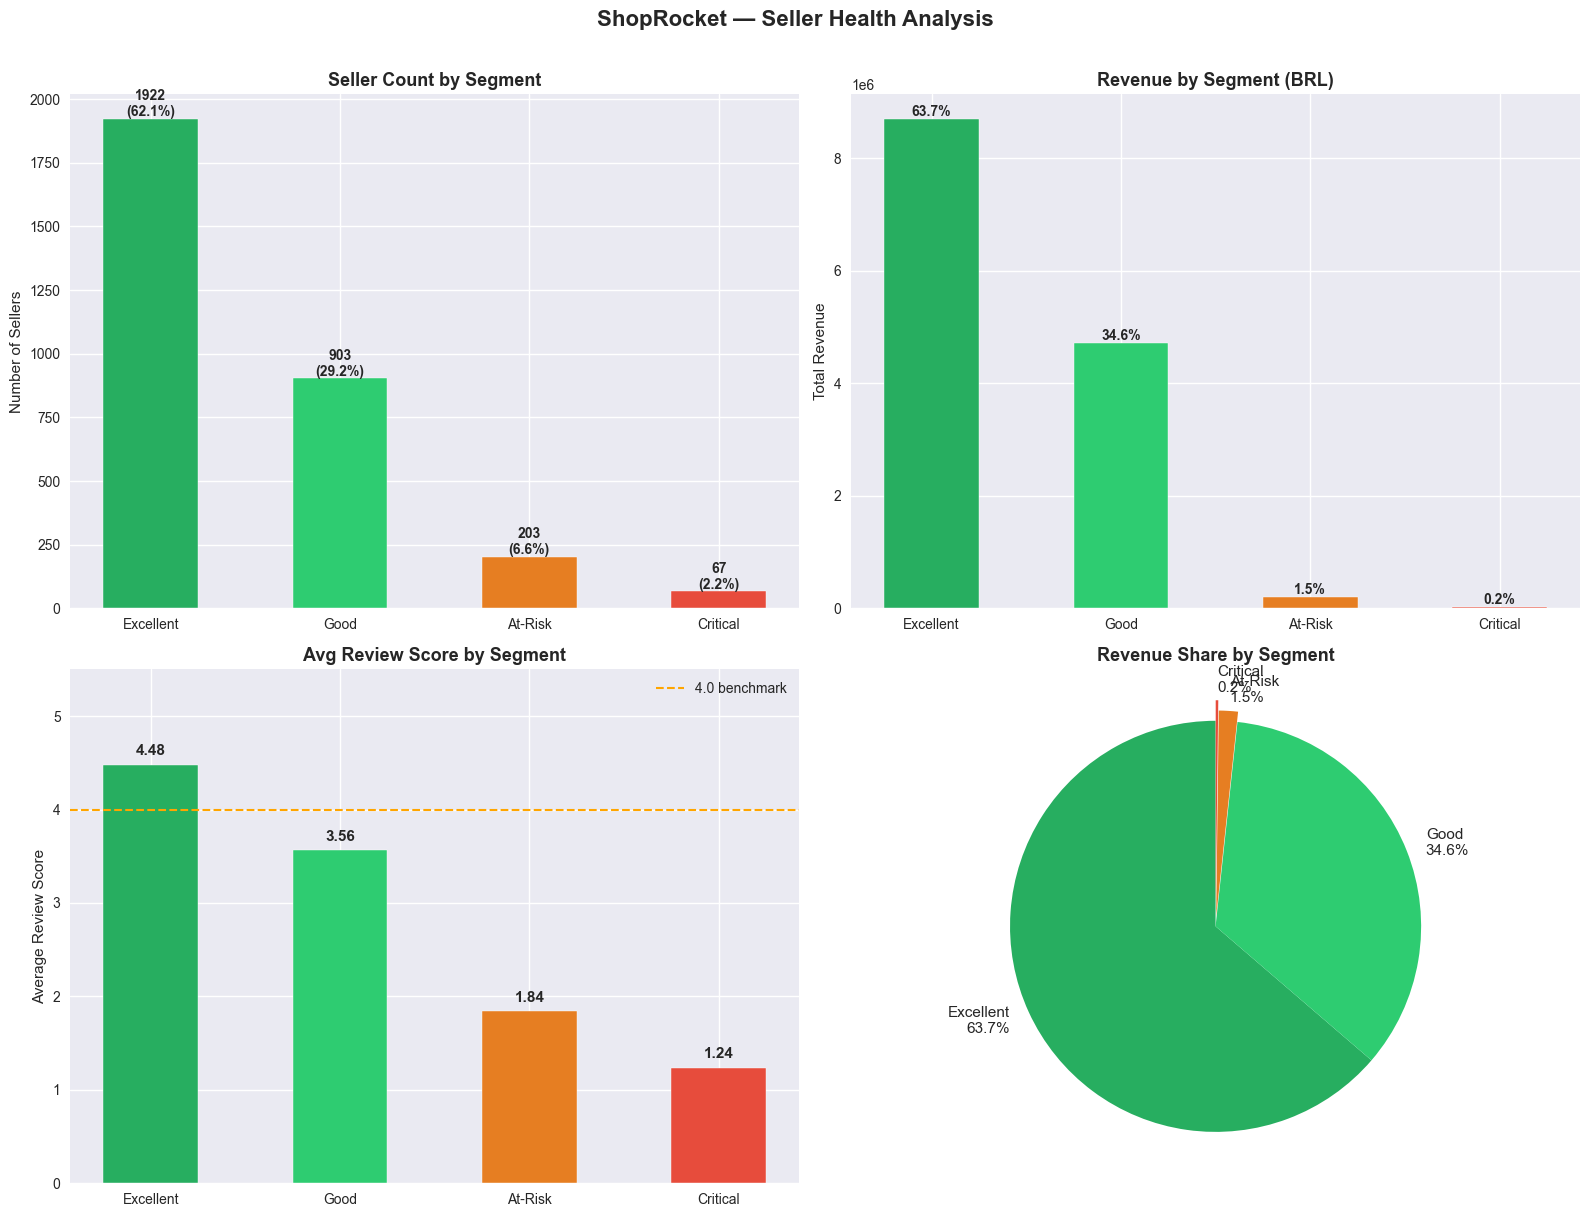

✅ Chart saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['#27ae60', '#2ecc71', '#e67e22', '#e74c3c']

# ── Chart 1 — Seller Count by Segment ─────────────────
axes[0,0].bar(seg_dist['segment'], 
              seg_dist['seller_count'],
              color=colors, edgecolor='white', width=0.5)
axes[0,0].set_title('Seller Count by Segment',
                    fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Number of Sellers')
for i, (val, pct) in enumerate(zip(seg_dist['seller_count'],
                                    seg_dist['seller_pct'])):
    axes[0,0].text(i, val + 10, f'{val}\n({pct}%)',
                  ha='center', fontweight='bold', fontsize=10)

# ── Chart 2 — Revenue by Segment ──────────────────────
axes[0,1].bar(seg_dist['segment'],
              seg_dist['total_revenue'],
              color=colors, edgecolor='white', width=0.5)
axes[0,1].set_title('Revenue by Segment (BRL)',
                    fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Total Revenue')
for i, (val, pct) in enumerate(zip(seg_dist['total_revenue'],
                                    seg_dist['revenue_pct'])):
    axes[0,1].text(i, val + 50000, f'{pct}%',
                  ha='center', fontweight='bold', fontsize=10)

# ── Chart 3 — Avg Review by Segment ───────────────────
bars = axes[1,0].bar(seg_dist['segment'],
                     seg_dist['avg_review'],
                     color=colors, edgecolor='white', width=0.5)
axes[1,0].set_title('Avg Review Score by Segment',
                    fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Average Review Score')
axes[1,0].set_ylim(0, 5.5)
axes[1,0].axhline(y=4.0, color='orange', 
                  linestyle='--', linewidth=1.5,
                  label='4.0 benchmark')
axes[1,0].legend()
for i, val in enumerate(seg_dist['avg_review']):
    axes[1,0].text(i, val + 0.1, f'{val:.2f}',
                  ha='center', fontweight='bold', fontsize=11)

# ── Chart 4 — Revenue % Pie ────────────────────────────
axes[1,1].pie(seg_dist['revenue_pct'],
              labels=[f"{s}\n{p}%" for s, p in 
                     zip(seg_dist['segment'], 
                         seg_dist['revenue_pct'])],
              colors=colors,
              explode=(0, 0, 0.05, 0.1),
              startangle=90,
              textprops={'fontsize': 11})
axes[1,1].set_title('Revenue Share by Segment',
                    fontsize=13, fontweight='bold')

plt.suptitle('ShopRocket — Seller Health Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/reports/chart_06_seller_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")